In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

EARTH_RADIUS_KM = 6371.0088

viirs = pd.read_csv(
    "viirs_night_2023_2024_eda.csv"
)

viirs["acq_date"] = pd.to_datetime(
    viirs["acq_date"]
)

print("Observations:", len(viirs))
print(
    "Date range:",
    viirs["acq_date"].min().date(),
    "to",
    viirs["acq_date"].max().date()
)

Observations: 323659
Date range: 2023-01-01 to 2024-12-31


In [56]:
TEST_START = "2024-01-01"
TEST_END = "2024-01-31"

test = viirs[
    (viirs["acq_date"] >= TEST_START) &
    (viirs["acq_date"] <= TEST_END)
].copy()

test = test.reset_index(drop=True)

print("Test observations:", len(test))
print("Unique dates:", test["acq_date"].nunique())

Test observations: 13609
Unique dates: 31


In [57]:
daily_objects = []

for date, day_data in test.groupby("acq_date"):

    coords_rad = np.radians(
        day_data[
            ["latitude", "longitude"]
        ].values
    )

    model = DBSCAN(
        eps=1.0 / EARTH_RADIUS_KM,
        min_samples=1,
        metric="haversine",
        algorithm="ball_tree"
    )

    labels = model.fit_predict(coords_rad)

    day_data = day_data.copy()
    day_data["spatial_object_id"] = labels

    daily_objects.append(day_data)

daily_objects = pd.concat(
    daily_objects,
    ignore_index=True
)

print(
    "Daily spatial objects:",
    daily_objects[
        ["acq_date", "spatial_object_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

Daily spatial objects: 6888


In [58]:
daily_objects["daily_object_id"] = (
    daily_objects["acq_date"].dt.strftime("%Y%m%d")
    + "_"
    + daily_objects["spatial_object_id"].astype(str)
)

print(
    "Unique daily objects:",
    daily_objects["daily_object_id"].nunique()
)

Unique daily objects: 6888


In [59]:
object_stats = (
    daily_objects
    .groupby(
        ["acq_date", "daily_object_id"]
    )
    .agg(
        centroid_lat=("latitude", "mean"),
        centroid_lon=("longitude", "mean"),
        detection_count=("latitude", "size"),
        mean_frp=("frp", "mean"),
        max_frp=("frp", "max"),
        mean_ti4=("bright_ti4", "mean"),
        max_ti4=("bright_ti4", "max"),
        mean_ti5=("bright_ti5", "mean"),
        max_ti5=("bright_ti5", "max")
    )
    .reset_index()
)

print("Spatial object table:", object_stats.shape)

display(object_stats.head())

Spatial object table: (6888, 11)


,acq_date,daily_object_id,centroid_lat,centroid_lon,detection_count,mean_frp,max_frp,mean_ti4,max_ti4,mean_ti5,max_ti5
0,2024-01-01,20240101_0,30.5579,79.1196,2,2.0950,2.2100,301.0900,304.9900,277.2550,277.2700
1,2024-01-01,20240101_1,30.0443,80.5822,1,1.6600,1.6600,309.7600,309.7600,277.5900,277.5900
2,2024-01-01,20240101_10,27.4692,95.4230,1,0.7700,0.7700,306.5600,306.5600,283.9700,283.9700
3,2024-01-01,20240101_100,21.7564,83.8412,2,3.3100,3.3100,314.2600,323.7400,289.6650,290.9700
4,2024-01-01,20240101_101,21.7341,83.9805,1,1.2100,1.2100,300.0300,300.0300,289.4000,289.4000


In [60]:
OBJECT_LINK_RADIUS_KM = 1.0
MAX_OBJECT_GAP_DAYS = 3

print(
    "Object linking radius:",
    OBJECT_LINK_RADIUS_KM,
    "km"
)

print(
    "Maximum temporal gap:",
    MAX_OBJECT_GAP_DAYS,
    "days"
)

Object linking radius: 1.0 km
Maximum temporal gap: 3 days


In [61]:
object_coords = np.radians(
    object_stats[
        ["centroid_lat", "centroid_lon"]
    ].values
)

object_stats["object_index"] = np.arange(
    len(object_stats)
)

print(
    "Objects to track:",
    len(object_stats)
)

Objects to track: 6888


In [62]:
parent = np.arange(
    len(object_stats),
    dtype=np.int32
)

size = np.ones(
    len(object_stats),
    dtype=np.int32
)


def find(x):

    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]

    return x


def union(a, b):

    root_a = find(a)
    root_b = find(b)

    if root_a == root_b:
        return

    if size[root_a] < size[root_b]:
        root_a, root_b = root_b, root_a

    parent[root_b] = root_a
    size[root_a] += size[root_b]

In [63]:
object_dates = {
    date: group.index.to_numpy()
    for date, group
    in object_stats.groupby("acq_date")
}

unique_dates = sorted(
    object_dates.keys()
)

link_count = 0

for current_date in unique_dates:

    current_indices = object_dates[
        current_date
    ]

    for gap in range(
        1,
        MAX_OBJECT_GAP_DAYS + 1
    ):

        previous_date = (
            current_date
            - pd.Timedelta(days=gap)
        )

        if previous_date not in object_dates:
            continue

        previous_indices = object_dates[
            previous_date
        ]

        current_coords = np.radians(
            object_stats.loc[
                current_indices,
                ["centroid_lat", "centroid_lon"]
            ].values
        )

        previous_coords = np.radians(
            object_stats.loc[
                previous_indices,
                ["centroid_lat", "centroid_lon"]
            ].values
        )

        previous_tree = DBSCAN(
            eps=OBJECT_LINK_RADIUS_KM
            / EARTH_RADIUS_KM,
            min_samples=1,
            metric="haversine",
            algorithm="ball_tree"
        )

        # Use BallTree directly for nearest spatial matching
        from sklearn.neighbors import BallTree

        tree = BallTree(
            previous_coords,
            metric="haversine"
        )

        neighbours = tree.query_radius(
            current_coords,
            r=OBJECT_LINK_RADIUS_KM
            / EARTH_RADIUS_KM
        )

        for local_i, matches in enumerate(
            neighbours
        ):

            current_idx = current_indices[
                local_i
            ]

            for local_j in matches:

                previous_idx = previous_indices[
                    local_j
                ]

                union(
                    current_idx,
                    previous_idx
                )

                link_count += 1

print(
    "Temporal object links:",
    link_count
)

Temporal object links: 7085


In [64]:
object_roots = np.array([
    find(i)
    for i in range(len(object_stats))
])

event_ids = (
    pd.factorize(object_roots)[0] + 1
)

object_stats["event_id"] = event_ids

print(
    "Candidate thermal events:",
    object_stats["event_id"].nunique()
)

Candidate thermal events: 3337


In [65]:
event_stats = (
    object_stats
    .groupby("event_id")
    .agg(
        start_date=("acq_date", "min"),
        end_date=("acq_date", "max"),
        active_days=("acq_date", "nunique"),
        spatial_objects=("daily_object_id", "count"),
        detections=("detection_count", "sum"),
        centroid_lat=("centroid_lat", "mean"),
        centroid_lon=("centroid_lon", "mean"),
        mean_frp=("mean_frp", "mean"),
        max_frp=("max_frp", "max")
    )
    .reset_index()
)

event_stats["duration_days"] = (
    event_stats["end_date"]
    - event_stats["start_date"]
).dt.days + 1

display(event_stats.head())

,event_id,start_date,end_date,active_days,spatial_objects,detections,centroid_lat,centroid_lon,mean_frp,max_frp,duration_days
0,1,2024-01-01,2024-01-01,1,1,2,30.5579,79.1196,2.0950,2.2100,1
1,2,2024-01-01,2024-01-01,1,1,1,30.0443,80.5822,1.6600,1.6600,1
2,3,2024-01-01,2024-01-29,23,23,33,27.4694,95.4220,0.9780,2.0200,29
3,4,2024-01-01,2024-01-17,17,17,39,21.7584,83.8428,1.9730,4.1900,17
4,5,2024-01-01,2024-01-01,1,1,1,21.7341,83.9805,1.2100,1.2100,1


In [66]:
print("========== TEMPORAL EVENT RESULTS ==========")

print(
    "Candidate events:",
    len(event_stats)
)

print("\nEvent statistics:")

display(
    event_stats[
        [
            "active_days",
            "duration_days",
            "spatial_objects",
            "detections"
        ]
    ].describe()
)

========== TEMPORAL EVENT RESULTS ==========
Candidate events: 3337

Event statistics:


,active_days,duration_days,spatial_objects,detections
count,3337.0000,3337.0000,3337.0000,3337.0000
mean,1.9865,2.3135,2.0641,4.0782
std,3.4306,4.3424,3.9917,17.6588
min,1.0000,1.0000,1.0000,1.0000
25%,1.0000,1.0000,1.0000,1.0000
50%,1.0000,1.0000,1.0000,1.0000
75%,1.0000,1.0000,1.0000,2.0000
max,31.0000,31.0000,66.0000,714.0000


In [67]:
for threshold in [1, 2, 3, 5, 7]:

    count = (
        event_stats["active_days"]
        >= threshold
    ).sum()

    print(
        f"Events active ≥ {threshold} days:",
        count
    )

Events active ≥ 1 days: 3337
Events active ≥ 2 days: 633
Events active ≥ 3 days: 391
Events active ≥ 5 days: 245
Events active ≥ 7 days: 180


In [68]:
display(
    event_stats
    .sort_values(
        "detections",
        ascending=False
    )
    .head(20)
)

,event_id,start_date,end_date,active_days,spatial_objects,detections,centroid_lat,centroid_lon,mean_frp,max_frp,duration_days
33,34,2024-01-01,2024-01-31,27,27,714,23.7697,86.3938,1.8710,5.1300,31
156,157,2024-01-01,2024-01-31,26,66,229,23.7877,86.3439,1.8428,4.5100,31
92,93,2024-01-01,2024-01-31,31,36,212,21.1054,72.6410,3.5936,15.6900,31
18,19,2024-01-01,2024-01-17,16,16,197,20.9665,85.1722,1.9722,4.6700,17
55,56,2024-01-01,2024-01-31,26,27,170,23.7774,86.2054,2.0954,7.3400,31
120,121,2024-01-01,2024-01-31,26,27,146,23.6839,86.3927,1.7701,5.1500,31
108,109,2024-01-01,2024-01-31,26,43,137,15.1756,76.6628,1.7716,5.7000,31
28,29,2024-01-01,2024-01-18,17,31,132,20.7967,85.2579,2.1929,8.9800,18
102,103,2024-01-01,2024-01-31,29,38,132,18.6868,73.0370,2.1061,4.8200,31
127,128,2024-01-01,2024-01-29,26,34,124,23.6790,86.0893,1.8821,6.4600,29


In [69]:
display(
    event_stats
    .sort_values(
        [
            "active_days",
            "detections"
        ],
        ascending=False
    )
    .head(20)
)

,event_id,start_date,end_date,active_days,spatial_objects,detections,centroid_lat,centroid_lon,mean_frp,max_frp,duration_days
92,93,2024-01-01,2024-01-31,31,36,212,21.1054,72.6410,3.5936,15.6900,31
102,103,2024-01-01,2024-01-31,29,38,132,18.6868,73.0370,2.1061,4.8200,31
6,7,2024-01-01,2024-01-31,29,29,46,21.4871,81.7688,1.5950,2.6700,31
33,34,2024-01-01,2024-01-31,27,27,714,23.7697,86.3938,1.8710,5.1300,31
188,189,2024-01-01,2024-01-31,27,30,120,22.0410,83.7362,2.4446,6.3400,31
169,170,2024-01-01,2024-01-31,27,27,94,22.0544,88.1240,2.0884,21.3700,31
148,149,2024-01-01,2024-01-31,27,34,93,23.1703,82.3412,1.5823,4.9700,31
112,113,2024-01-01,2024-01-31,27,27,56,15.1715,76.3784,1.3757,3.1500,31
156,157,2024-01-01,2024-01-31,26,66,229,23.7877,86.3439,1.8428,4.5100,31
55,56,2024-01-01,2024-01-31,26,27,170,23.7774,86.2054,2.0954,7.3400,31


In [70]:
event_centroids = (
    object_stats
    .groupby("event_id")
    .agg(
        centroid_lat=("centroid_lat", "mean"),
        centroid_lon=("centroid_lon", "mean")
    )
)

objects_check = object_stats.merge(
    event_centroids,
    on="event_id",
    suffixes=("", "_event")
)

In [71]:
def haversine_km(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return (
        2
        * EARTH_RADIUS_KM
        * np.arcsin(np.sqrt(a))
    )

In [72]:
event_centroids = (
    object_stats
    .groupby("event_id")
    .agg(
        event_centroid_lat=("centroid_lat", "mean"),
        event_centroid_lon=("centroid_lon", "mean")
    )
)

objects_check = object_stats.merge(
    event_centroids,
    on="event_id",
    how="left"
)

objects_check["distance_from_event_centroid_km"] = (
    haversine_km(
        objects_check["centroid_lat"],
        objects_check["centroid_lon"],
        objects_check["event_centroid_lat"],
        objects_check["event_centroid_lon"]
    )
)

event_extent = (
    objects_check
    .groupby("event_id")
    ["distance_from_event_centroid_km"]
    .max()
)

print("========== EVENT SPATIAL EXTENT ==========")
print(event_extent.describe())

print("\nLargest events spatially:")

display(
    event_extent
    .sort_values(ascending=False)
    .head(20)
)

========== EVENT SPATIAL EXTENT ==========
count   3337.0000
mean       0.0601
std        0.1779
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        2.4196
Name: distance_from_event_centroid_km, dtype: float64

Largest events spatially:


event_id
109    2.4196
15     2.0179
1937   1.6849
2024   1.4844
16     1.4577
189    1.4324
22     1.3961
29     1.3711
18     1.3637
128    1.3573
157    1.3430
146    1.3340
2732   1.3328
38     1.3318
45     1.2569
2156   1.2279
290    1.1931
72     1.1689
190    1.1298
194    1.1237
Name: distance_from_event_centroid_km, dtype: float64

In [73]:
event_size = event_stats["detections"]

print("========== EVENT SIZE ==========")
print(event_size.describe())

print("\nLargest events by detections:")

display(
    event_stats
    .sort_values(
        "detections",
        ascending=False
    )
    .head(20)
)

========== EVENT SIZE ==========
count   3337.0000
mean       4.0782
std       17.6588
min        1.0000
25%        1.0000
50%        1.0000
75%        2.0000
max      714.0000
Name: detections, dtype: float64

Largest events by detections:


,event_id,start_date,end_date,active_days,spatial_objects,detections,centroid_lat,centroid_lon,mean_frp,max_frp,duration_days
33,34,2024-01-01,2024-01-31,27,27,714,23.7697,86.3938,1.8710,5.1300,31
156,157,2024-01-01,2024-01-31,26,66,229,23.7877,86.3439,1.8428,4.5100,31
92,93,2024-01-01,2024-01-31,31,36,212,21.1054,72.6410,3.5936,15.6900,31
18,19,2024-01-01,2024-01-17,16,16,197,20.9665,85.1722,1.9722,4.6700,17
55,56,2024-01-01,2024-01-31,26,27,170,23.7774,86.2054,2.0954,7.3400,31
120,121,2024-01-01,2024-01-31,26,27,146,23.6839,86.3927,1.7701,5.1500,31
108,109,2024-01-01,2024-01-31,26,43,137,15.1756,76.6628,1.7716,5.7000,31
28,29,2024-01-01,2024-01-18,17,31,132,20.7967,85.2579,2.1929,8.9800,18
102,103,2024-01-01,2024-01-31,29,38,132,18.6868,73.0370,2.1061,4.8200,31
127,128,2024-01-01,2024-01-29,26,34,124,23.6790,86.0893,1.8821,6.4600,29


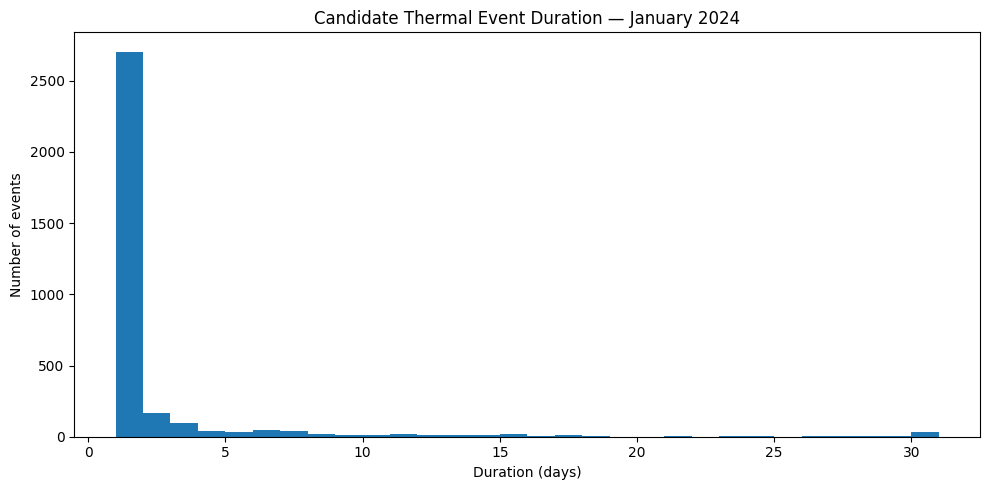

In [74]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_stats["duration_days"],
    bins=30
)

plt.xlabel("Duration (days)")
plt.ylabel("Number of events")

plt.title(
    "Candidate Thermal Event Duration — January 2024"
)

plt.tight_layout()
plt.show()

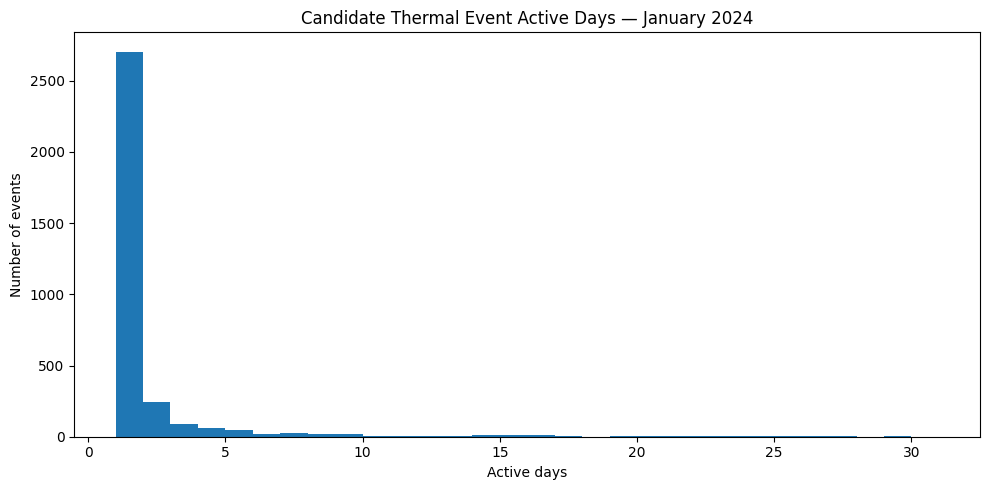

In [75]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_stats["active_days"],
    bins=30
)

plt.xlabel("Active days")
plt.ylabel("Number of events")

plt.title(
    "Candidate Thermal Event Active Days — January 2024"
)

plt.tight_layout()
plt.show()

In [76]:
print("========== PERSISTENCE ==========")

for threshold in [2, 3, 5, 7, 10, 14]:

    count = (
        event_stats["active_days"] >= threshold
    ).sum()

    percentage = (
        count
        / len(event_stats)
        * 100
    )

    print(
        f"≥ {threshold:2} active days : "
        f"{count:,} events "
        f"({percentage:.2f}%)"
    )

========== PERSISTENCE ==========
≥  2 active days : 633 events (18.97%)
≥  3 active days : 391 events (11.72%)
≥  5 active days : 245 events (7.34%)
≥  7 active days : 180 events (5.39%)
≥ 10 active days : 119 events (3.57%)
≥ 14 active days : 89 events (2.67%)


In [77]:
print("========== LARGEST EVENTS ==========")

display(
    event_stats
    .sort_values(
        "detections",
        ascending=False
    )
    .head(20)
)

========== LARGEST EVENTS ==========


,event_id,start_date,end_date,active_days,spatial_objects,detections,centroid_lat,centroid_lon,mean_frp,max_frp,duration_days
33,34,2024-01-01,2024-01-31,27,27,714,23.7697,86.3938,1.8710,5.1300,31
156,157,2024-01-01,2024-01-31,26,66,229,23.7877,86.3439,1.8428,4.5100,31
92,93,2024-01-01,2024-01-31,31,36,212,21.1054,72.6410,3.5936,15.6900,31
18,19,2024-01-01,2024-01-17,16,16,197,20.9665,85.1722,1.9722,4.6700,17
55,56,2024-01-01,2024-01-31,26,27,170,23.7774,86.2054,2.0954,7.3400,31
120,121,2024-01-01,2024-01-31,26,27,146,23.6839,86.3927,1.7701,5.1500,31
108,109,2024-01-01,2024-01-31,26,43,137,15.1756,76.6628,1.7716,5.7000,31
28,29,2024-01-01,2024-01-18,17,31,132,20.7967,85.2579,2.1929,8.9800,18
102,103,2024-01-01,2024-01-31,29,38,132,18.6868,73.0370,2.1061,4.8200,31
127,128,2024-01-01,2024-01-29,26,34,124,23.6790,86.0893,1.8821,6.4600,29


In [78]:
print("========== MOST PERSISTENT EVENTS ==========")

display(
    event_stats
    .sort_values(
        ["active_days", "detections"],
        ascending=False
    )
    .head(20)
)

========== MOST PERSISTENT EVENTS ==========


,event_id,start_date,end_date,active_days,spatial_objects,detections,centroid_lat,centroid_lon,mean_frp,max_frp,duration_days
92,93,2024-01-01,2024-01-31,31,36,212,21.1054,72.6410,3.5936,15.6900,31
102,103,2024-01-01,2024-01-31,29,38,132,18.6868,73.0370,2.1061,4.8200,31
6,7,2024-01-01,2024-01-31,29,29,46,21.4871,81.7688,1.5950,2.6700,31
33,34,2024-01-01,2024-01-31,27,27,714,23.7697,86.3938,1.8710,5.1300,31
188,189,2024-01-01,2024-01-31,27,30,120,22.0410,83.7362,2.4446,6.3400,31
169,170,2024-01-01,2024-01-31,27,27,94,22.0544,88.1240,2.0884,21.3700,31
148,149,2024-01-01,2024-01-31,27,34,93,23.1703,82.3412,1.5823,4.9700,31
112,113,2024-01-01,2024-01-31,27,27,56,15.1715,76.3784,1.3757,3.1500,31
156,157,2024-01-01,2024-01-31,26,66,229,23.7877,86.3439,1.8428,4.5100,31
55,56,2024-01-01,2024-01-31,26,27,170,23.7774,86.2054,2.0954,7.3400,31


In [79]:
print("========== LARGEST SPATIAL EVENTS ==========")

display(
    event_extent
    .sort_values(
        ascending=False
    )
    .head(20)
)

========== LARGEST SPATIAL EVENTS ==========


event_id
109    2.4196
15     2.0179
1937   1.6849
2024   1.4844
16     1.4577
189    1.4324
22     1.3961
29     1.3711
18     1.3637
128    1.3573
157    1.3430
146    1.3340
2732   1.3328
38     1.3318
45     1.2569
2156   1.2279
290    1.1931
72     1.1689
190    1.1298
194    1.1237
Name: distance_from_event_centroid_km, dtype: float64

In [80]:
print("=" * 60)
print("FINAL JANUARY 2024 EVENT-FORMATION SUMMARY")
print("=" * 60)

print(
    f"VIIRS detections       : {len(test):,}"
)

print(
    f"Daily spatial objects  : "
    f"{object_stats['daily_object_id'].nunique():,}"
)

print(
    f"Candidate events       : "
    f"{event_stats['event_id'].nunique():,}"
)

print(
    f"Events ≥2 active days  : "
    f"{(event_stats['active_days'] >= 2).sum():,}"
)

print(
    f"Events ≥3 active days  : "
    f"{(event_stats['active_days'] >= 3).sum():,}"
)

print(
    f"Events ≥7 active days  : "
    f"{(event_stats['active_days'] >= 7).sum():,}"
)

print(
    f"Maximum event duration : "
    f"{event_stats['duration_days'].max()} days"
)

print(
    f"Maximum spatial extent : "
    f"{event_extent.max():.3f} km"
)

FINAL JANUARY 2024 EVENT-FORMATION SUMMARY
VIIRS detections       : 13,609
Daily spatial objects  : 6,888
Candidate events       : 3,337
Events ≥2 active days  : 633
Events ≥3 active days  : 391
Events ≥7 active days  : 180
Maximum event duration : 31 days
Maximum spatial extent : 2.420 km


In [82]:
print(daily_objects.columns.tolist())
print(object_stats.columns.tolist())

['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'year', 'lat_grid', 'lon_grid', 'spatial_object_id', 'daily_object_id']
['acq_date', 'daily_object_id', 'centroid_lat', 'centroid_lon', 'detection_count', 'mean_frp', 'max_frp', 'mean_ti4', 'max_ti4', 'mean_ti5', 'max_ti5', 'object_index', 'event_id']


In [83]:
daily_objects = daily_objects.merge(
    object_stats[
        [
            "acq_date",
            "daily_object_id",
            "event_id"
        ]
    ],
    on=[
        "acq_date",
        "daily_object_id"
    ],
    how="left"
)

print(daily_objects.shape)
print(
    daily_objects["event_id"].notna().sum(),
    "detections mapped to events"
)

(13609, 21)
13609 detections mapped to events


In [84]:
print(daily_objects.columns.tolist())

['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'year', 'lat_grid', 'lon_grid', 'spatial_object_id', 'daily_object_id', 'event_id']


In [85]:
daily_objects[
    [
        "acq_date",
        "daily_object_id",
        "event_id",
        "latitude",
        "longitude",
        "frp",
        "bright_ti4",
        "bright_ti5"
    ]
].to_csv(
    "viirs_poc_detection_event_mapping.csv",
    index=False
)

print("Saved detection → event mapping.")

Saved detection → event mapping.


In [86]:
print(daily_objects.shape)
print(daily_objects.columns.tolist())
print(daily_objects["event_id"].isna().sum())

(13609, 21)
['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'type', 'year', 'lat_grid', 'lon_grid', 'spatial_object_id', 'daily_object_id', 'event_id']
0
